# EULP Data Preprocessing

**Purpose.** Load and preprocess EULP data; create modeling-ready features and targets.

**Inputs.** Raw EULP dataset files placed in `data/`.

**Outputs.** Processed dataset saved to `outputs/`.

**Reproducibility.** Set a random seed and keep paths configurable (see `Configuration` cell below).


In [1]:
# import modules
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

import warnings
warnings.simplefilter(action='ignore')


### **Read and load dataset**

In [2]:
# Read raw EULP data
df_eulp_raw = pd.read_csv('./02_EULP_national/01_Data/eulp.csv', keep_default_na=False, index_col=0)
df_eulp_raw.head()

,in.sqft,in.ashrae_iecc_climate_zone_2004,in.bedrooms,in.ceiling_fan,in.clothes_dryer,in.clothes_washer,in.clothes_washer_presence,in.cooking_range,in.cooling_setpoint,in.cooling_setpoint_has_offset,...,in.units_represented,in.usage_level,in.vacancy_status,in.vintage,in.water_heater_efficiency,in.water_heater_fuel,in.water_heater_in_unit,in.window_areas,in.windows,out.site_energy.total.energy_consumption.kwh
bldg_id,,,,,,,,,,,,,,,,,,,,,
1,1690,4A,3,Standard Efficiency,"Electric, 80% Usage","Standard, 80% Usage",Yes,"Electric, 80% Usage",78F,Yes,...,1,Low,Occupied,2000s,Electric Standard,Electricity,Yes,F18 B18 L18 R18,"Double, Low-E, Non-metal, Air, M-Gain",26021.780310
2,1690,6B,3,Standard Efficiency,"Electric, 100% Usage","EnergyStar, 100% Usage",Yes,"Electric, 100% Usage",75F,Yes,...,1,Medium,Occupied,1950s,Natural Gas Standard,Natural Gas,Yes,F12 B12 L12 R12,"Single, Clear, Non-metal",57007.598390
4,2176,2A,4,None,"Electric, 80% Usage","EnergyStar, 80% Usage",Yes,"Electric, 80% Usage",72F,No,...,1,Low,Vacant,1970s,Electric Standard,Electricity,Yes,F12 B12 L12 R12,"Single, Clear, Metal",12548.717080
5,2176,4A,3,Standard Efficiency,"Electric, 100% Usage","EnergyStar, 100% Usage",Yes,"Electric, 100% Usage",70F,No,...,1,Medium,Occupied,2000s,Natural Gas Standard,Natural Gas,Yes,F9 B9 L9 R9,"Double, Low-E, Non-metal, Air, M-Gain",33710.499830
6,1690,2A,3,Standard Efficiency,"Electric, 120% Usage","EnergyStar, 120% Usage",Yes,"Electric, 120% Usage",78F,No,...,1,High,Occupied,1960s,Electric Standard,Electricity,Yes,F12 B12 L12 R12,"Single, Clear, Non-metal",9921.628004


In [3]:
df_eulp_raw.info()

<class 'pandas.DataFrame'>
Index: 548916 entries, 1 to 550000
Columns: 108 entries, in.sqft to out.site_energy.total.energy_consumption.kwh
dtypes: float64(1), int64(4), object(1), str(102)
memory usage: 456.5+ MB


### **Split Compound Variables**

In [4]:
import re
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

COMPOUND_COLS = [
"in.clothes_dryer", "in.clothes_washer", "in.cooking_range",
"in.cooling_setpoint_offset_period", "in.dishwasher", "in.ducts",
"in.heating_setpoint_offset_period", "in.hvac_cooling_efficiency",
"in.hvac_heating_efficiency", "in.insulation_foundation_wall",
"in.insulation_roof", "in.insulation_wall",
"in.refrigerator", "in.window_areas"
]

In [5]:
# Compound columns
def split_type_usage_columns(df, cols, drop_original=True):
    """
    Split columns of format: 'Type, XX% Usage'
    Creates:
        <col>_type
        <col>_usage
    Only splits when comma exists.
    """

    df = df.copy()
    created_cols = []

    for col in cols:
        if col not in df.columns:
            print(f"[skip] Column not found: {col}")
            continue

        type_col = f"{col}_type"
        usage_col = f"{col}_usage"

        type_list = []
        usage_list = []

        for value in df[col]:

            if pd.isna(value):
                type_list.append(np.nan)
                usage_list.append(np.nan)
                continue

            if isinstance(value, str) and "," in value:
                part1, part2 = value.split(",", 1)
                type_list.append(part1.strip())
                usage_list.append(part2.strip())
            else:
                # No comma → keep entire value as type
                type_list.append(value)
                usage_list.append(value)

        df[type_col] = type_list
        df[usage_col] = usage_list

        created_cols.extend([type_col, usage_col])

        if drop_original:
            df.drop(columns=[col], inplace=True)

    print("=== Split complete ===")
    print(f"Columns processed: {len([c for c in cols if c in df.columns])}")
    print("New columns created:")
    for c in created_cols:
        print(" -", c)

    return df

In [6]:
df_split_type_usage = split_type_usage_columns(
    df_eulp_raw,
    cols=[
        "in.clothes_dryer",
        "in.clothes_washer",
        "in.cooking_range",
        "in.dishwasher",
        "in.refrigerator"
    ]
)

=== Split complete ===
Columns processed: 0
New columns created:
 - in.clothes_dryer_type
 - in.clothes_dryer_usage
 - in.clothes_washer_type
 - in.clothes_washer_usage
 - in.cooking_range_type
 - in.cooking_range_usage
 - in.dishwasher_type
 - in.dishwasher_usage
 - in.refrigerator_type
 - in.refrigerator_usage


In [7]:
# offset_period
## The period and offset for the dwelling unit's cooling setpoint. Default for the day is from 9am to 5pm and for the night is 10pm to 7am

def split_offset_period_columns(df, cols, drop_original=True):
    """
    Generic splitter for variables like:
        'Night Setback +2h'
        'Day Setup -4h'
        'None'

    Creates:
        <col>_type
        <col>_offset

    No numeric conversion.
    Preserves 'None'.
    """

    df = df.copy()
    created_cols = []

    for col in cols:
        if col not in df.columns:
            print(f"[skip] Column not found: {col}")
            continue

        type_col = f"{col}_type"
        offset_col = f"{col}_offset"

        type_list = []
        offset_list = []

        for value in df[col]:

            # Preserve literal "None"
            if value == "None":
                type_list.append("None")
                offset_list.append("None")
                continue

            if isinstance(value, str):

                # Find signed hour pattern like +2h or -5h
                match = re.search(r"[+-]\d+h", value)

                if match:
                    offset = match.group()
                    offset_list.append(offset)

                    type_part = value.replace(offset, "").strip()
                    type_list.append(type_part)
                else:
                    # No offset present
                    type_list.append(value)
                    offset_list.append(np.nan)

            else:
                type_list.append(value)
                offset_list.append(np.nan)

        df[type_col] = type_list
        df[offset_col] = offset_list

        created_cols.extend([type_col, offset_col])

        if drop_original:
            df.drop(columns=[col], inplace=True)

    print("=== Offset split complete ===")
    print("New columns created:")
    for c in created_cols:
        print(" -", c)

    return df

In [8]:
df_split_offset = split_offset_period_columns(
    df_split_type_usage,
    cols=[
        "in.cooling_setpoint_offset_period",
        "in.heating_setpoint_offset_period"       
    ]
)

=== Offset split complete ===
New columns created:
 - in.cooling_setpoint_offset_period_type
 - in.cooling_setpoint_offset_period_offset
 - in.heating_setpoint_offset_period_type
 - in.heating_setpoint_offset_period_offset


In [9]:
# Duct Leakage
def split_ducts(df, col="in.ducts", drop_original=True):

    df = df.copy()

    if col not in df.columns:
        print(f"[skip] Column not found: {col}")
        return df

    leakage_col = f"{col}_leakage"
    insulation_col = f"{col}_insulation"

    leakage_list = []
    insulation_list = []

    for value in df[col]:

        if value == "None":
            leakage_list.append("None")
            insulation_list.append("None")
            continue

        if isinstance(value, str) and "," in value:
            p1, p2 = value.split(",", 1)
            leakage_list.append(p1.strip())
            insulation_list.append(p2.strip())
        else:
            leakage_list.append(value)
            insulation_list.append(np.nan)

    df[leakage_col] = leakage_list
    df[insulation_col] = insulation_list

    if drop_original:
        df.drop(columns=[col], inplace=True)

    print("=== Duct split complete ===")
    print(" - Created:", leakage_col)
    print(" - Created:", insulation_col)

    return df

In [10]:
# First split ducts
df_split_ducts = split_ducts(df_split_offset)

=== Duct split complete ===
 - Created: in.ducts_leakage
 - Created: in.ducts_insulation


In [11]:
def split_insulation_columns(df, cols, drop_original=True):

    df = df.copy()
    created_cols = []

    for col in cols:
        if col not in df.columns:
            print(f"[skip] Column not found: {col}")
            continue

        material_col = f"{col}_material"
        rvalue_col = f"{col}_r_value"

        material_list = []
        rvalue_list = []

        for value in df[col]:

            if value == "None":
                material_list.append("None")
                rvalue_list.append("None")
                continue

            if isinstance(value, str):

                # Case 1: contains R-value like R-38
                r_match = re.search(r"R-\d+", value)

                if r_match:
                    r_value = r_match.group()
                    rvalue_list.append(r_value)

                    # remove only that R-x token
                    material_part = value.replace(r_value, "").replace(",", "").strip()
                    material_list.append(material_part)

                else:
                    # Case 2: no R-x → split by last comma
                    if "," in value:
                        left, right = value.rsplit(",", 1)
                        material_list.append(left.strip())
                        rvalue_list.append(right.strip())
                    else:
                        material_list.append(value)
                        rvalue_list.append(value)

            else:
                material_list.append(value)
                rvalue_list.append(np.nan)

        df[material_col] = material_list
        df[rvalue_col] = rvalue_list

        created_cols.extend([material_col, rvalue_col])

        if drop_original:
            df.drop(columns=[col], inplace=True)

    print("=== Insulation split complete ===")
    print("New columns created:")
    for c in created_cols:
        print(" -", c)

    return df

In [12]:
df_split_insulation = split_insulation_columns(
    df_split_ducts,
    cols=[
        "in.insulation_foundation_wall",
        "in.insulation_rim_joist",
        "in.insulation_roof",
        "in.insulation_wall"
    ]
)

=== Insulation split complete ===
New columns created:
 - in.insulation_foundation_wall_material
 - in.insulation_foundation_wall_r_value
 - in.insulation_rim_joist_material
 - in.insulation_rim_joist_r_value
 - in.insulation_roof_material
 - in.insulation_roof_r_value
 - in.insulation_wall_material
 - in.insulation_wall_r_value


In [13]:
# window to wall ratio
def split_window_areas(df, col="in.window_areas", drop_original=True):

    df = df.copy()

    if col not in df.columns:
        print(f"[skip] Column not found: {col}")
        return df

    front_col = f"{col}_front"
    back_col = f"{col}_back"
    left_col = f"{col}_left"
    right_col = f"{col}_right"

    front_list = []
    back_list = []
    left_list = []
    right_list = []

    for value in df[col]:

        if value == "None":
            front_list.append("None")
            back_list.append("None")
            left_list.append("None")
            right_list.append("None")
            continue

        if isinstance(value, str):

            tokens = value.split()

            # Initialize default
            f = b = l = r = np.nan

            for token in tokens:
                if token.startswith("F"):
                    f = token
                elif token.startswith("B"):
                    b = token
                elif token.startswith("L"):
                    l = token
                elif token.startswith("R"):
                    r = token

            front_list.append(f)
            back_list.append(b)
            left_list.append(l)
            right_list.append(r)

        else:
            front_list.append(np.nan)
            back_list.append(np.nan)
            left_list.append(np.nan)
            right_list.append(np.nan)

    df[front_col] = front_list
    df[back_col] = back_list
    df[left_col] = left_list
    df[right_col] = right_list

    if drop_original:
        df.drop(columns=[col], inplace=True)

    print("=== Window areas split complete, new columns created: ===")
    print(" - ", front_col)
    print(" - ", back_col)
    print(" - ", left_col)
    print(" - ", right_col)

    return df

In [14]:
df_eulp_split = split_window_areas(df_split_insulation)

=== Window areas split complete, new columns created: ===
 -  in.window_areas_front
 -  in.window_areas_back
 -  in.window_areas_left
 -  in.window_areas_right


In [15]:
df_eulp_split.info()
df_eulp_split.head()

<class 'pandas.DataFrame'>
Index: 548916 entries, 1 to 550000
Columns: 123 entries, in.sqft to in.window_areas_right
dtypes: float64(1), int64(4), object(1), str(117)
memory usage: 519.3+ MB


,in.sqft,in.ashrae_iecc_climate_zone_2004,in.bedrooms,in.ceiling_fan,in.clothes_washer_presence,in.cooling_setpoint,in.cooling_setpoint_has_offset,in.cooling_setpoint_offset_magnitude,in.corridor,in.dehumidifier,...,in.insulation_rim_joist_material,in.insulation_rim_joist_r_value,in.insulation_roof_material,in.insulation_roof_r_value,in.insulation_wall_material,in.insulation_wall_r_value,in.window_areas_front,in.window_areas_back,in.window_areas_left,in.window_areas_right
bldg_id,,,,,,,,,,,,,,,,,,,,,
1,1690,4A,3,Standard Efficiency,Yes,78F,Yes,5F,Not Applicable,None,...,None,None,Unfinished,Uninsulated,Wood Stud,R-11,F18,B18,L18,R18
2,1690,6B,3,Standard Efficiency,Yes,75F,Yes,2F,Not Applicable,None,...,Uninsulated,Uninsulated,Unfinished,Uninsulated,Wood Stud,Uninsulated,F12,B12,L12,R12
4,2176,2A,4,None,Yes,72F,No,0F,Not Applicable,None,...,None,None,Unfinished,Uninsulated,Wood Stud,Uninsulated,F12,B12,L12,R12
5,2176,4A,3,Standard Efficiency,Yes,70F,No,0F,Not Applicable,None,...,None,None,Unfinished,Uninsulated,Wood Stud,R-11,F9,B9,L9,R9
6,1690,2A,3,Standard Efficiency,Yes,78F,No,0F,Not Applicable,None,...,Uninsulated,Uninsulated,Unfinished,Uninsulated,"Brick, 12-in, 3-wythe",Uninsulated,F12,B12,L12,R12


In [16]:
# save the DataFrame to a CSV file
df_eulp_split.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_eulp_split.csv', index=True)

### **New Variable Groups**

In [17]:
# 1. Base Column Groups
numerical_cols_base = [
"in.bedrooms", "in.geometry_stories", "in.sqft", "in.cooling_setpoint", "in.cooling_setpoint_offset_magnitude", 
"in.door_area", "in.eaves", "in.geometry_building_number_units_mf", "in.geometry_building_number_units_sfa", "in.heating_setpoint",
"in.heating_setpoint_offset_magnitude", "in.hot_water_fixtures", "in.infiltration", "in.lighting_interior_use", "in.lighting_other_use",
"in.occupants", "in.pv_system_size", "in.hvac_cooling_partial_space_conditioning", "in.insulation_ceiling",
"in.insulation_floor", "in.misc_extra_refrigerator", "in.neighbors",
"in.plug_load_diversity", "in.plug_loads"
]

categorical_cols_base = [
"in.ashrae_iecc_climate_zone_2004", "in.ceiling_fan", "in.clothes_washer_presence", "in.cooling_setpoint_has_offset",
"in.corridor", "in.dehumidifier", "in.doors", "in.electric_vehicle", "in.geometry_attic_type", "in.geometry_building_horizontal_location_mf",
"in.geometry_building_horizontal_location_sfa", "in.geometry_building_level_mf", "in.geometry_building_type_recs",
"in.geometry_foundation_type", "in.geometry_garage", "in.geometry_wall_exterior_finish", "in.geometry_wall_type",
"in.has_pv", "in.heating_fuel", "in.heating_setpoint_has_offset", "in.holiday_lighting", "in.hot_water_distribution",
"in.hvac_cooling_type", "in.hvac_has_ducts", "in.hvac_has_shared_system", "in.hvac_has_zonal_electric_heating",
"in.hvac_heating_type", "in.hvac_heating_type_and_fuel", "in.hvac_secondary_heating_efficiency",
"in.hvac_secondary_heating_type_and_fuel", "in.hvac_shared_efficiencies", "in.hvac_system_is_faulted",
"in.hvac_system_single_speed_ac_airflow", "in.hvac_system_single_speed_ac_charge",
"in.hvac_system_single_speed_ashp_airflow", "in.hvac_system_single_speed_ashp_charge",
"in.insulation_slab", "in.interior_shading", "in.lighting", "in.mechanical_ventilation", "in.misc_freezer",
"in.misc_gas_fireplace", "in.misc_gas_grill", "in.misc_gas_lighting", "in.misc_hot_tub_spa",
"in.misc_pool", "in.misc_pool_heater", "in.misc_pool_pump", "in.misc_well_pump",
"in.natural_ventilation", "in.orientation", "in.overhangs", "in.pv_orientation",
"in.radiant_barrier", "in.roof_material", "in.schedules", "in.solar_hot_water",
"in.tenure", "in.units_represented", "in.usage_level", "in.vacancy_status",
"in.vintage", "in.water_heater_efficiency", "in.water_heater_fuel", "in.water_heater_in_unit", "in.windows"
]

ordinal_cols_base = ["in.federal_poverty_level", "in.income_recs_2020"]

In [18]:
# df_eulp_split = pd.read_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_eulp_split.csv', 
                           # keep_default_na=False, index_col=0)

In [19]:
# 2. Updated Column Groups
numerical_cols_derived = [
"in.clothes_dryer_usage", "in.clothes_washer_usage", "in.cooking_range_usage", "in.dishwasher_usage", 
"in.refrigerator_usage", "in.cooling_setpoint_offset_period_offset", "in.heating_setpoint_offset_period_offset", 
"in.ducts_leakage", "in.ducts_insulation", "in.insulation_foundation_wall_r_value", 
"in.insulation_rim_joist_r_value", "in.insulation_wall_r_value", "in.insulation_roof_r_value", 
"in.window_areas_front", "in.window_areas_back", "in.window_areas_left", "in.window_areas_right" 
]

categorical_cols_derived = [
"in.clothes_dryer_type", "in.clothes_washer_type", "in.cooking_range_type", "in.dishwasher_type", 
"in.refrigerator_type", "in.cooling_setpoint_offset_period_type", "in.heating_setpoint_offset_period_type", 
"in.insulation_foundation_wall_material", "in.insulation_rim_joist_material", "in.insulation_roof_material", 
"in.insulation_wall_material"
]

NUM_COLS = numerical_cols_base + numerical_cols_derived
CAT_COLS = categorical_cols_base + categorical_cols_derived

df_num = df_eulp_split[NUM_COLS]
df_cat = df_eulp_split[CAT_COLS]
df_ord = df_eulp_split[ordinal_cols_base]

In [20]:
# save the DataFrame to a CSV file
df_num.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_num.csv', index=True)

In [21]:
# save the DataFrame to a CSV file
df_cat.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_cat.csv', index=True)

In [22]:
# save the DataFrame to a CSV file
df_ord.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_ord.csv', index=True)

### **Clean Numeric Variables**

In [23]:
# df_num = pd.read_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_num.csv', 
                    # keep_default_na=False, index_col=0)

In [24]:
# Initialize clean dataset
df_num_clean = df_num.copy()

# 1. Keep As Is (Pure Numeric Columns)
cols_keep_as_is = [
    "in.bedrooms",
    "in.geometry_stories",
    "in.sqft",
]
# Already preserved via df_num.copy()

# 2. Extract Numeric Values (Remove Units/Text)
cols_extract_numeric = [
    "in.cooling_setpoint",
    "in.cooling_setpoint_offset_magnitude",
    "in.door_area",
    "in.eaves",
    "in.heating_setpoint",
    "in.heating_setpoint_offset_magnitude",
    "in.infiltration",
    "in.window_areas_front",
    "in.window_areas_back",
    "in.window_areas_left",
    "in.window_areas_right",
]

def extract_float(x):
    if pd.isna(x):
        return pd.NA
    match = re.search(r"-?\d+(\.\d+)?", str(x))
    return float(match.group()) if match else pd.NA

for col in cols_extract_numeric:
    df_num_clean[col] = df_num[col].map(extract_float)


# 2b. Occupants (Handle Top-Coded "10+")
def clean_occupants(x):
    if pd.isna(x):
        return pd.NA
    x_str = str(x).strip()
    if x_str.endswith("+"):
        return int(x_str.replace("+", ""))
    match = re.search(r"\d+", x_str)
    return int(match.group()) if match else pd.NA

df_num_clean["in.occupants"] = df_num["in.occupants"].map(clean_occupants)


# 3. Structural Numeric Columns ("None" = Not Applicable)
cols_structural_units = [
    "in.geometry_building_number_units_mf",
    "in.geometry_building_number_units_sfa",
]

def extract_int_structural(x):
    if pd.isna(x):
        return 0
    x_str = str(x).strip()
    if x_str == "None":
        return 0
    match = re.search(r"\d+", x_str)
    return int(match.group()) if match else 0

for col in cols_structural_units:

    has_none = df_num[col].astype(str).str.strip().eq("None").any()

    if has_none:
        df_num_clean[col + "_exist"] = (
            df_num[col].astype(str).str.strip() != "None"
        ).astype(int)

    df_num_clean[col] = df_num[col].map(extract_int_structural)


# 4. Percent Columns (Convert % → Decimal)
cols_percent = [
    "in.hot_water_fixtures",
    "in.lighting_interior_use",
    "in.lighting_other_use",
    "in.hvac_cooling_partial_space_conditioning",
    "in.plug_load_diversity",
    "in.plug_loads",
    "in.clothes_dryer_usage",
    "in.clothes_washer_usage",
    "in.cooking_range_usage",
    "in.dishwasher_usage",
    "in.refrigerator_usage",
    "in.ducts_leakage",
]

def extract_percent_decimal(x):
    if pd.isna(x):
        return 0.0
    x_str = str(x).strip()
    if x_str == "None":
        return 0.0
    match = re.search(r"-?\d+(\.\d+)?", x_str)
    return float(match.group()) / 100 if match else 0.0

for col in cols_percent:

    has_none = df_num[col].astype(str).str.strip().eq("None").any()

    if has_none:
        df_num_clean[col + "_exist"] = (
            df_num[col].astype(str).str.strip() != "None"
        ).astype(int)

    df_num_clean[col] = df_num[col].map(extract_percent_decimal)


# 5. Insulation / Offset / R-Value Columns
cols_r_offset = [
    "in.cooling_setpoint_offset_period_offset",
    "in.heating_setpoint_offset_period_offset",
    "in.ducts_insulation",
    "in.insulation_foundation_wall_r_value",
    "in.insulation_rim_joist_r_value",
    "in.insulation_wall_r_value",
    "in.insulation_roof_r_value",
    "in.insulation_ceiling",
    "in.insulation_floor",
    "in.misc_extra_refrigerator",
    "in.neighbors",
    "in.pv_system_size",
]

def extract_numeric_r(x):
    if pd.isna(x):
        return 0.0
    x_str = str(x).strip()

    # structural absence
    if x_str == "None":
        return 0.0
    # uninsulated → R0
    if x_str.lower() == "uninsulated":
        return 0.0
    # remove text prefixes like R-, r-, etc.
    x_str = re.sub(r"[a-zA-Z\-]+", "", x_str)
    # extract numeric value
    match = re.search(r"\d+(\.\d+)?", x_str)
    return float(match.group()) if match else 0.0

for col in cols_r_offset:

    has_none = df_num[col].astype(str).str.strip().eq("None").any()

    if has_none:
        df_num_clean[col + "_exist"] = (
            df_num[col].astype(str).str.strip() != "None"
        ).astype(int)

    df_num_clean[col] = df_num[col].map(extract_numeric_r)

In [25]:
df_num_clean.head()

,in.bedrooms,in.geometry_stories,in.sqft,in.cooling_setpoint,in.cooling_setpoint_offset_magnitude,in.door_area,in.eaves,in.geometry_building_number_units_mf,in.geometry_building_number_units_sfa,in.heating_setpoint,...,in.cooling_setpoint_offset_period_offset_exist,in.heating_setpoint_offset_period_offset_exist,in.ducts_insulation_exist,in.insulation_foundation_wall_r_value_exist,in.insulation_rim_joist_r_value_exist,in.insulation_ceiling_exist,in.insulation_floor_exist,in.misc_extra_refrigerator_exist,in.neighbors_exist,in.pv_system_size_exist
bldg_id,,,,,,,,,,,,,,,,,,,,,
1,3,2,1690,78.0,5.0,20.0,2.0,0,0,68.0,...,1,0,1,0,0,1,0,0,1,0
2,3,1,1690,75.0,2.0,20.0,2.0,0,0,70.0,...,1,1,1,1,1,1,1,0,1,0
4,4,1,2176,72.0,0.0,20.0,2.0,0,0,55.0,...,0,0,1,0,0,1,1,0,1,0
5,3,1,2176,70.0,0.0,20.0,2.0,0,0,67.0,...,0,0,1,0,0,1,0,0,1,0
6,3,1,1690,78.0,0.0,20.0,2.0,0,0,68.0,...,0,1,0,1,1,1,1,1,1,0


In [26]:
# save the DataFrame to a CSV file
df_num_clean.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_num_clean.csv', index=True)

### **Encode Categorical & Ordinal Variables**
Adaptive Hybrid Encoding (AHE) for categorical variables

In [27]:
# df_cat = pd.read_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_cat.csv', 
                     # keep_default_na=False, index_col=0)
# df_ord = pd.read_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_ord.csv', 
                     # keep_default_na=False, index_col=0)

In [28]:
CARDINALITY_THRESHOLD = 15

def frequency_encode(series):
    freq = series.value_counts(normalize=True)
    return series.map(freq)

def encode_categorical(df_cat, threshold=15):

    df_cat = df_cat.copy()

    # treat None as structural category
    df_cat = df_cat.fillna("None")

    low_card_cols = []
    high_card_cols = []

    for col in df_cat.columns:

        n_unique = df_cat[col].nunique()

        if n_unique <= threshold:
            low_card_cols.append(col)
        else:
            high_card_cols.append(col)

    print("Low-cardinality:", len(low_card_cols))
    print("High-cardinality:", len(high_card_cols))

    df_encoded = pd.DataFrame(index=df_cat.index)

    # ONE HOT
    df_onehot = pd.get_dummies(
        df_cat[low_card_cols].astype(str),
        prefix_sep="="
    )

    df_encoded = pd.concat([df_encoded, df_onehot], axis=1)

    # FREQUENCY ENCODING
    for col in high_card_cols:
        df_encoded[col + "_freq"] = frequency_encode(df_cat[col])

    return df_encoded, low_card_cols, high_card_cols

In [29]:
df_cat_encoded, low_cols, high_cols = encode_categorical(df_cat)

Low-cardinality: 76
High-cardinality: 1


In [30]:
df_cat_encoded = df_cat_encoded.astype(int)
df_cat_encoded.head()

,in.ashrae_iecc_climate_zone_2004=1A,in.ashrae_iecc_climate_zone_2004=2A,in.ashrae_iecc_climate_zone_2004=2B,in.ashrae_iecc_climate_zone_2004=3A,in.ashrae_iecc_climate_zone_2004=3B,in.ashrae_iecc_climate_zone_2004=3C,in.ashrae_iecc_climate_zone_2004=4A,in.ashrae_iecc_climate_zone_2004=4B,in.ashrae_iecc_climate_zone_2004=4C,in.ashrae_iecc_climate_zone_2004=5A,...,in.insulation_rim_joist_material=None,in.insulation_rim_joist_material=Uninsulated,in.insulation_roof_material=Finished,in.insulation_roof_material=Unfinished,in.insulation_wall_material=Brick 12-in 3-wythe,"in.insulation_wall_material=Brick, 12-in, 3-wythe",in.insulation_wall_material=CMU 6-in Hollow,"in.insulation_wall_material=CMU, 6-in Hollow",in.insulation_wall_material=Wood Stud,in.hvac_heating_type_and_fuel_freq
bldg_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
5,0,0,0,0,0,0,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
6,0,1,0,0,0,0,0,0,0,0,...,0,1,0,1,0,1,0,0,0,0


In [31]:
# save the DataFrame to a CSV file
df_cat_encoded.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_cat_encoded.csv', index=True)

In [32]:
# Encode ordinal variables
# Remove possible spaces
df_ord = df_ord.apply(lambda x: x.str.strip())

# Federal Poverty Level
poverty_map = {
    "0-100%": 1,
    "100-150%": 2,
    "150-200%": 3,
    "200-300%": 4,
    "300-400%": 5,
    "400%+": 6
}

df_ord["in.federal_poverty_level_ord"] = (
    df_ord["in.federal_poverty_level"]
    .map(poverty_map)
    .astype("Int64")
)

# RECS Income
income_map = {
    "<20000": 1,
    "20000-39999": 2,
    "40000-59999": 3,
    "60000-99999": 4,
    "100000-149999": 5,
    "150000+": 6
}

df_ord["in.income_recs_2020_ord"] = (
    df_ord["in.income_recs_2020"]
    .map(income_map)
    .astype("Int64")
)

# Keep only encoded columns
df_ord_encoded = df_ord[
    ["in.federal_poverty_level_ord", "in.income_recs_2020_ord"]
]

In [33]:
df_ord_encoded.head()

,in.federal_poverty_level_ord,in.income_recs_2020_ord
bldg_id,,
1,5,4
2,6,5
4,1,1
5,6,5
6,4,2


In [34]:
df_feature_clean = pd.concat([
    df_num_clean,
    df_cat_encoded,
    df_ord_encoded
], axis=1)

df_feature_clean.head()

,in.bedrooms,in.geometry_stories,in.sqft,in.cooling_setpoint,in.cooling_setpoint_offset_magnitude,in.door_area,in.eaves,in.geometry_building_number_units_mf,in.geometry_building_number_units_sfa,in.heating_setpoint,...,in.insulation_roof_material=Finished,in.insulation_roof_material=Unfinished,in.insulation_wall_material=Brick 12-in 3-wythe,"in.insulation_wall_material=Brick, 12-in, 3-wythe",in.insulation_wall_material=CMU 6-in Hollow,"in.insulation_wall_material=CMU, 6-in Hollow",in.insulation_wall_material=Wood Stud,in.hvac_heating_type_and_fuel_freq,in.federal_poverty_level_ord,in.income_recs_2020_ord
bldg_id,,,,,,,,,,,,,,,,,,,,,
1,3,2,1690,78.0,5.0,20.0,2.0,0,0,68.0,...,0,1,0,0,0,0,1,0,5,4
2,3,1,1690,75.0,2.0,20.0,2.0,0,0,70.0,...,0,1,0,0,0,0,1,0,6,5
4,4,1,2176,72.0,0.0,20.0,2.0,0,0,55.0,...,0,1,0,0,0,0,1,0,1,1
5,3,1,2176,70.0,0.0,20.0,2.0,0,0,67.0,...,0,1,0,0,0,0,1,0,6,5
6,3,1,1690,78.0,0.0,20.0,2.0,0,0,68.0,...,0,1,0,1,0,0,0,0,4,2


### **Handle missing values**

In [35]:
# Function to calculate missing values by column
def missing_values_table(df_feature_clean):
        # Total missing values
        mis_val_df_feature_clean = df_feature_clean.isnull().sum()

        # Percentage of missing values
        mis_val_df_feature_clean_percent = 100 * df_feature_clean.isnull().sum() / len(df_feature_clean)

        # Make a table with the results
        mis_val_df_feature_clean_table = pd.concat([mis_val_df_feature_clean, mis_val_df_feature_clean], axis=1)

        # Rename the columns
        mis_val_df_feature_clean_table_ren_columns = mis_val_df_feature_clean_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_df_feature_clean_table_ren_columns = mis_val_df_feature_clean_table_ren_columns[
            mis_val_df_feature_clean_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(df_feature_clean.shape[1]) + " columns.\n"
            "There are " + str(mis_val_df_feature_clean_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        # Return the dataframe with missing information
        return mis_val_df_feature_clean_table_ren_columns


In [36]:
missing_values_table(df_feature_clean)

Your selected dataframe has 335 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


### **Drop constant features**

In [37]:
### Identify zero variance features
from sklearn.feature_selection import VarianceThreshold

var_thres=VarianceThreshold(threshold=0)
var_thres.fit(df_feature_clean)

var_thres.get_support()

constant_columns = [column for column in df_feature_clean.columns
                    if column not in df_feature_clean.columns[var_thres.get_support()]]

print(len(constant_columns))

for feature in constant_columns:
     print(feature)

24
in.door_area
in.eaves
in.lighting_interior_use
in.lighting_other_use
in.dehumidifier=None
in.doors=Fiberglass
in.electric_vehicle=None
in.holiday_lighting=No Exterior Use
in.hot_water_distribution=Uninsulated
in.hvac_secondary_heating_efficiency=None
in.hvac_secondary_heating_type_and_fuel=None
in.hvac_system_is_faulted=No
in.hvac_system_single_speed_ac_airflow=None
in.hvac_system_single_speed_ac_charge=None
in.hvac_system_single_speed_ashp_airflow=None
in.hvac_system_single_speed_ashp_charge=None
in.interior_shading=Summer = 0.7, Winter = 0.85
in.mechanical_ventilation=None
in.natural_ventilation=Cooling Season, 7 days/wk
in.overhangs=None
in.schedules=Stochastic
in.solar_hot_water=None
in.units_represented=1
in.hvac_heating_type_and_fuel_freq


In [38]:
df_feature_clean.info()

<class 'pandas.DataFrame'>
Index: 548916 entries, 1 to 550000
Columns: 335 entries, in.bedrooms to in.income_recs_2020_ord
dtypes: Int64(2), float64(35), int64(298)
memory usage: 1.4 GB


In [39]:
# Remove zero-variance columns
df_feature_processed = df_feature_clean.drop(columns=constant_columns)

In [40]:
# Check dimensional expansion
print("Original features:", df_eulp_raw.shape[1] - 1)
print("Processed features:", df_feature_processed.shape[1])

Original features: 107
Processed features: 311


In [41]:
print(df_feature_processed.index.equals(df_eulp_raw.index))

True


### **Process target variable, energy use (kWh).**

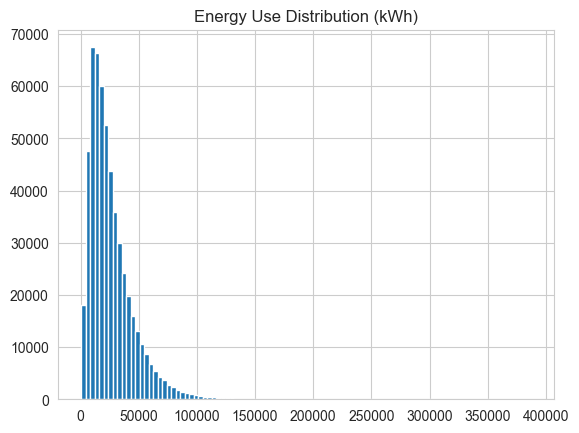

In [42]:
import matplotlib.pyplot as plt

COL_TAR = "out.site_energy.total.energy_consumption.kwh"

df_eulp_raw[COL_TAR].hist(bins=100)
plt.title("Energy Use Distribution (kWh)")
plt.show()

In [43]:
df_eulp_raw[COL_TAR].describe(percentiles=[0.01,0.05,0.95,0.99])

count    548916.000000
mean      25856.360825
std       19462.531435
min         416.453990
1%         2298.307292
5%         5347.081672
95%       62983.464045
99%       94005.901368
max      387903.886000
Name: out.site_energy.total.energy_consumption.kwh, dtype: float64

In [44]:
lower = df_eulp_raw[COL_TAR].quantile(0.01)
upper = df_eulp_raw[COL_TAR].quantile(0.99)

df_eulp_raw[df_eulp_raw[COL_TAR] > upper]

,in.sqft,in.ashrae_iecc_climate_zone_2004,in.bedrooms,in.ceiling_fan,in.clothes_dryer,in.clothes_washer,in.clothes_washer_presence,in.cooking_range,in.cooling_setpoint,in.cooling_setpoint_has_offset,...,in.units_represented,in.usage_level,in.vacancy_status,in.vintage,in.water_heater_efficiency,in.water_heater_fuel,in.water_heater_in_unit,in.window_areas,in.windows,out.site_energy.total.energy_consumption.kwh
bldg_id,,,,,,,,,,,,,,,,,,,,,
145,2176,6A,4,Standard Efficiency,"Electric, 80% Usage","Standard, 80% Usage",Yes,"Electric, 80% Usage",78F,Yes,...,1,Low,Occupied,1940s,Electric Standard,Electricity,Yes,F15 B15 L15 R15,"Double, Clear, Non-metal, Air",131977.22960
165,3301,6A,3,Standard Efficiency,"Electric, 100% Usage","EnergyStar, 100% Usage",Yes,"Electric, 100% Usage",72F,No,...,1,Medium,Occupied,1960s,Fuel Oil Standard,Fuel Oil,Yes,F9 B9 L9 R9,"Single, Clear, Metal",120034.58350
219,2176,6A,3,Standard Efficiency,"Gas, 80% Usage","EnergyStar, 80% Usage",Yes,"Electric, 80% Usage",72F,No,...,1,Low,Occupied,1950s,Natural Gas Standard,Natural Gas,Yes,F12 B12 L12 R12,"Single, Clear, Non-metal",134751.14730
258,1690,6A,3,None,"Electric, 120% Usage","EnergyStar, 120% Usage",Yes,"Electric, 120% Usage",70F,No,...,1,High,Occupied,1940s,Propane Standard,Propane,Yes,F15 B15 L15 R15,"Single, Clear, Metal",113744.69220
285,3301,5A,3,Standard Efficiency,"Gas, 100% Usage","EnergyStar, 100% Usage",Yes,"Gas, 100% Usage",72F,No,...,1,Medium,Occupied,1980s,Natural Gas Standard,Natural Gas,Yes,F15 B15 L15 R15,"Double, Clear, Metal, Air",131899.56580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549694,2176,5A,4,Standard Efficiency,"Gas, 100% Usage","Standard, 100% Usage",Yes,"Electric, 100% Usage",72F,Yes,...,1,Medium,Occupied,<1940,Natural Gas Standard,Natural Gas,Yes,F12 B12 L12 R12,"Single, Clear, Non-metal",100141.79850
549837,8194,4A,4,None,None,None,None,"Electric, 100% Usage",65F,Yes,...,1,Medium,Occupied,1960s,Natural Gas Standard,Natural Gas,Yes,F15 B15 L15 R15,"Double, Clear, Non-metal, Air",108319.06750
549845,12291,4A,3,None,None,None,None,"Gas, 100% Usage",70F,Yes,...,1,Medium,Occupied,<1940,Natural Gas Standard,Natural Gas,No,F18 B18 L18 R18,"Double, Clear, Metal, Air, Exterior Clear Storm",150682.78370


In [45]:
# log transform energy use
df_eulp_processed = pd.concat(
    [
        df_feature_processed,
        df_eulp_raw.loc[df_feature_processed.index, COL_TAR]
    ],
    axis=1
)

print(df_eulp_processed.shape)
print(df_eulp_processed[COL_TAR].isna().sum())

(548916, 312)
0


In [46]:
df_eulp_processed["energy_kwh_log"] = np.log1p(df_eulp_processed[COL_TAR])

In [47]:
df_eulp_processed.head()

,in.bedrooms,in.geometry_stories,in.sqft,in.cooling_setpoint,in.cooling_setpoint_offset_magnitude,in.geometry_building_number_units_mf,in.geometry_building_number_units_sfa,in.heating_setpoint,in.heating_setpoint_offset_magnitude,in.hot_water_fixtures,...,in.insulation_roof_material=Unfinished,in.insulation_wall_material=Brick 12-in 3-wythe,"in.insulation_wall_material=Brick, 12-in, 3-wythe",in.insulation_wall_material=CMU 6-in Hollow,"in.insulation_wall_material=CMU, 6-in Hollow",in.insulation_wall_material=Wood Stud,in.federal_poverty_level_ord,in.income_recs_2020_ord,out.site_energy.total.energy_consumption.kwh,energy_kwh_log
bldg_id,,,,,,,,,,,,,,,,,,,,,
1,3,2,1690,78.0,5.0,0,0,68.0,0.0,0.5,...,1,0,0,0,0,1,5,4,26021.780310,10.166728
2,3,1,1690,75.0,2.0,0,0,70.0,3.0,1.0,...,1,0,0,0,0,1,6,5,57007.598390,10.950957
4,4,1,2176,72.0,0.0,0,0,55.0,0.0,0.5,...,1,0,0,0,0,1,1,1,12548.717080,9.437453
5,3,1,2176,70.0,0.0,0,0,67.0,0.0,1.0,...,1,0,0,0,0,1,6,5,33710.499830,10.425594
6,3,1,1690,78.0,0.0,0,0,68.0,6.0,2.0,...,1,0,1,0,0,0,4,2,9921.628004,9.202573


In [48]:
# save the final processed DataFrame to a CSV file
df_eulp_processed.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/df_eulp_processed.csv', index=True)

### **Define X, y variable**

In [49]:
# target variable is "energy_kwh_log"
X_eulp_clean = df_feature_processed
y_eulp_clean = df_eulp_processed['energy_kwh_log']

In [50]:
print(y_eulp_clean.describe())

count    548916.000000
mean          9.894735
std           0.767913
min           6.034174
25%           9.415448
50%           9.945057
75%          10.431888
max          12.868515
Name: energy_kwh_log, dtype: float64


### **Tain Test split**
random_state fixes randomness
ensures reproducible results
42 is just a popular convention

In [51]:
# split dataset into train and test (80/20)
from sklearn.model_selection import train_test_split

X_train_eulp_clean, X_test_eulp_clean, y_train_eulp_clean, y_test_eulp_clean = train_test_split(
    X_eulp_clean,
    y_eulp_clean,
    test_size=0.2,
    random_state=42)
    # A fixed random seed (42) was used to ensure reproducibility.

X_train_eulp_clean.shape, X_test_eulp_clean.shape

((439132, 311), (109784, 311))

### **Perform scaling**
Why:
ElasticNet depends heavily on feature variance → StandardScaler works best.
Neural networks work with either, but StandardScaler is more stable for tabular data.
MinMaxScaler is very sensitive to outliers. One extreme value compresses all others. EULP dataset likely contains: large homes, high energy use, extreme insulation values, So MinMax scaling may distort the feature distribution.

| Model           | Preferred scaler             |
| --------------- | ---------------------------- |
| ElasticNet      | **StandardScaler**           |
| Random Forest   | none needed                  |
| XGBoost         | none needed                  |
| Neural Networks | **StandardScaler or MinMax** |


In [52]:
# scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_eulp_clean)
X_test_scaled  = scaler.transform(X_test_eulp_clean)

In [53]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(439132, 311)
(109784, 311)


In [54]:
# save the final processed DataFrame to a CSV file
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_eulp_clean.columns,
    index=X_train_eulp_clean.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_eulp_clean.columns,
    index=X_test_eulp_clean.index
)

X_train_scaled.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/X_train_scaled.csv', index=True)
X_test_scaled.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/X_test_scaled.csv', index=True)

y_train_eulp_clean.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/y_train.csv', index=True)
y_test_eulp_clean.to_csv('./02_EULP_national/03_Outcomes/01-Processed_Datasets/y_test.csv', index=True)

In [55]:
# Save the Scaler
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [56]:
# Load later
# scaler = joblib.load("scaler.pkl")